In [1]:
!pip install pmdarima

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
df = pd.read_csv(r'C:\Users\APC\2526-LTXLDL-Project-1.5\processed\kpi_daily_2023.csv')
df['pickup_date'] = pd.to_datetime(df['pickup_date'])

In [3]:
df = df.sort_values('pickup_date').reset_index(drop=True)

# Set index là ngày tháng để ARIMA hiểu
df.set_index('pickup_date', inplace=True)

In [4]:
# 2. CHIA TẬP TRAIN / TEST
train_size = int(0.8 * len(df))
train, test = df.iloc[:train_size], df.iloc[train_size:]
y_train = train['total_trips']
y_test = test['total_trips']

print(f"Train size: {len(y_train)}")
print(f"Test size: {len(y_test)}")

Train size: 292
Test size: 73


Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[7] intercept   : AIC=5941.955, Time=0.46 sec
 ARIMA(0,0,0)(0,1,0)[7] intercept   : AIC=6326.643, Time=0.03 sec
 ARIMA(1,0,0)(1,1,0)[7] intercept   : AIC=5991.705, Time=0.21 sec
 ARIMA(0,0,1)(0,1,1)[7] intercept   : AIC=6074.893, Time=0.32 sec
 ARIMA(0,0,0)(0,1,0)[7]             : AIC=6324.973, Time=0.02 sec
 ARIMA(1,0,1)(0,1,0)[7] intercept   : AIC=6060.035, Time=0.07 sec
 ARIMA(1,0,1)(1,1,1)[7] intercept   : AIC=5934.735, Time=1.06 sec
 ARIMA(1,0,1)(1,1,0)[7] intercept   : AIC=5985.691, Time=0.21 sec
 ARIMA(1,0,1)(2,1,1)[7] intercept   : AIC=5945.488, Time=1.05 sec
 ARIMA(1,0,1)(1,1,2)[7] intercept   : AIC=5943.785, Time=1.52 sec
 ARIMA(1,0,1)(0,1,2)[7] intercept   : AIC=5943.471, Time=0.59 sec
 ARIMA(1,0,1)(2,1,0)[7] intercept   : AIC=5969.174, Time=0.50 sec
 ARIMA(1,0,1)(2,1,2)[7] intercept   : AIC=5947.620, Time=0.77 sec
 ARIMA(0,0,1)(1,1,1)[7] intercept   : AIC=6111.409, Time=0.35 sec
 ARIMA(1,0,0)(1,1,1)[7] intercept

C:\Users\APC\AppData\Local\Temp\ipykernel_3056\1773896744.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fc = model.predict(n_periods=1)[0]


KẾT QUẢ (SARIMA + Rolling):
RMSE: 7464.13
MAE:  5520.27
R2 Score: 0.7887
----------------------------------------


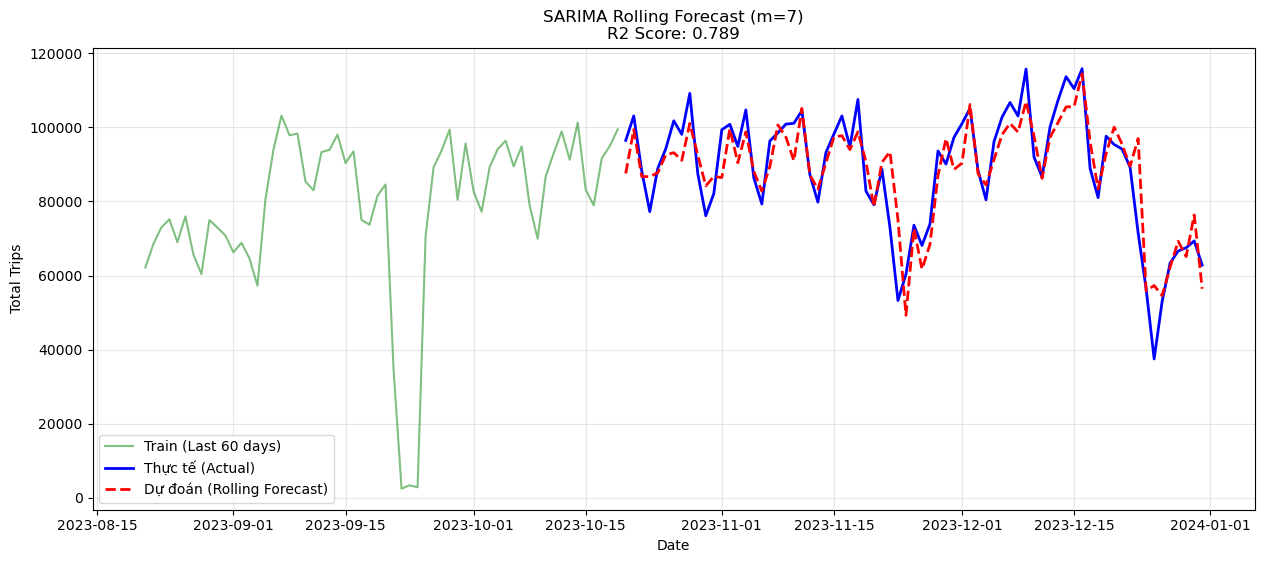

In [ ]:
# 3. (AUTO-ARIMA)
# m=7: Phải có để model hiểu chu kỳ tuần
model = auto_arima(
    y_train,
    start_p=1, start_q=1,
    max_p=3, max_q=3,
    m=7,              
    start_P=0, seasonal=True, 
    d=None, D=1, 
    trace=True,
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True
)

print(f"\nBest Param: {model.order}")
print(f"Seasonal Param: {model.seasonal_order}")

# THỰC HIỆN ROLLING FORECAST (WALK-FORWARD VALIDATION)
# Dự đoán 1 ngày -> Lấy kết quả thực tế update vào model -> Dự đoán ngày tiếp theo.

predictions = []

# Loop qua từng điểm dữ liệu trong tập Test
for new_ob in y_test:
    # Dự đoán 1 bước tiếp theo
    fc = model.predict(n_periods=1)[0]
    predictions.append(fc)
    
    # Cập nhật model với dữ liệu thực tế mới nhất
    model.update(new_ob)

# ĐÁNH GIÁ KẾT QUẢ
y_pred = pd.Series(predictions, index=y_test.index)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"KẾT QUẢ (SARIMA + Rolling):")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print("-" * 40)

plt.figure(figsize=(15, 6))
plt.plot(y_train.index[-60:], y_train[-60:], label='Train (Last 60 days)', color='green', alpha=0.5)
plt.plot(y_test.index, y_test, label='Thực tế (Actual)', color='blue', linewidth=2)
plt.plot(y_pred.index, y_pred, label='Dự đoán (Rolling Forecast)', color='red', linestyle='--', linewidth=2)

plt.title(f'SARIMA Rolling Forecast (m=7)\nR2 Score: {r2:.3f}')
plt.xlabel('Date')
plt.ylabel('Total Trips')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()